In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='MS')
)['Sales'].sum().reset_index()
monthly_sales.columns = ['Date', 'Sales']

regional = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
yearly = df.groupby('Year')['Sales'].sum()
monthly_avg = df.groupby('Month')['Sales'].mean()

print("All data ready for dashboard!")

All data ready for dashboard!


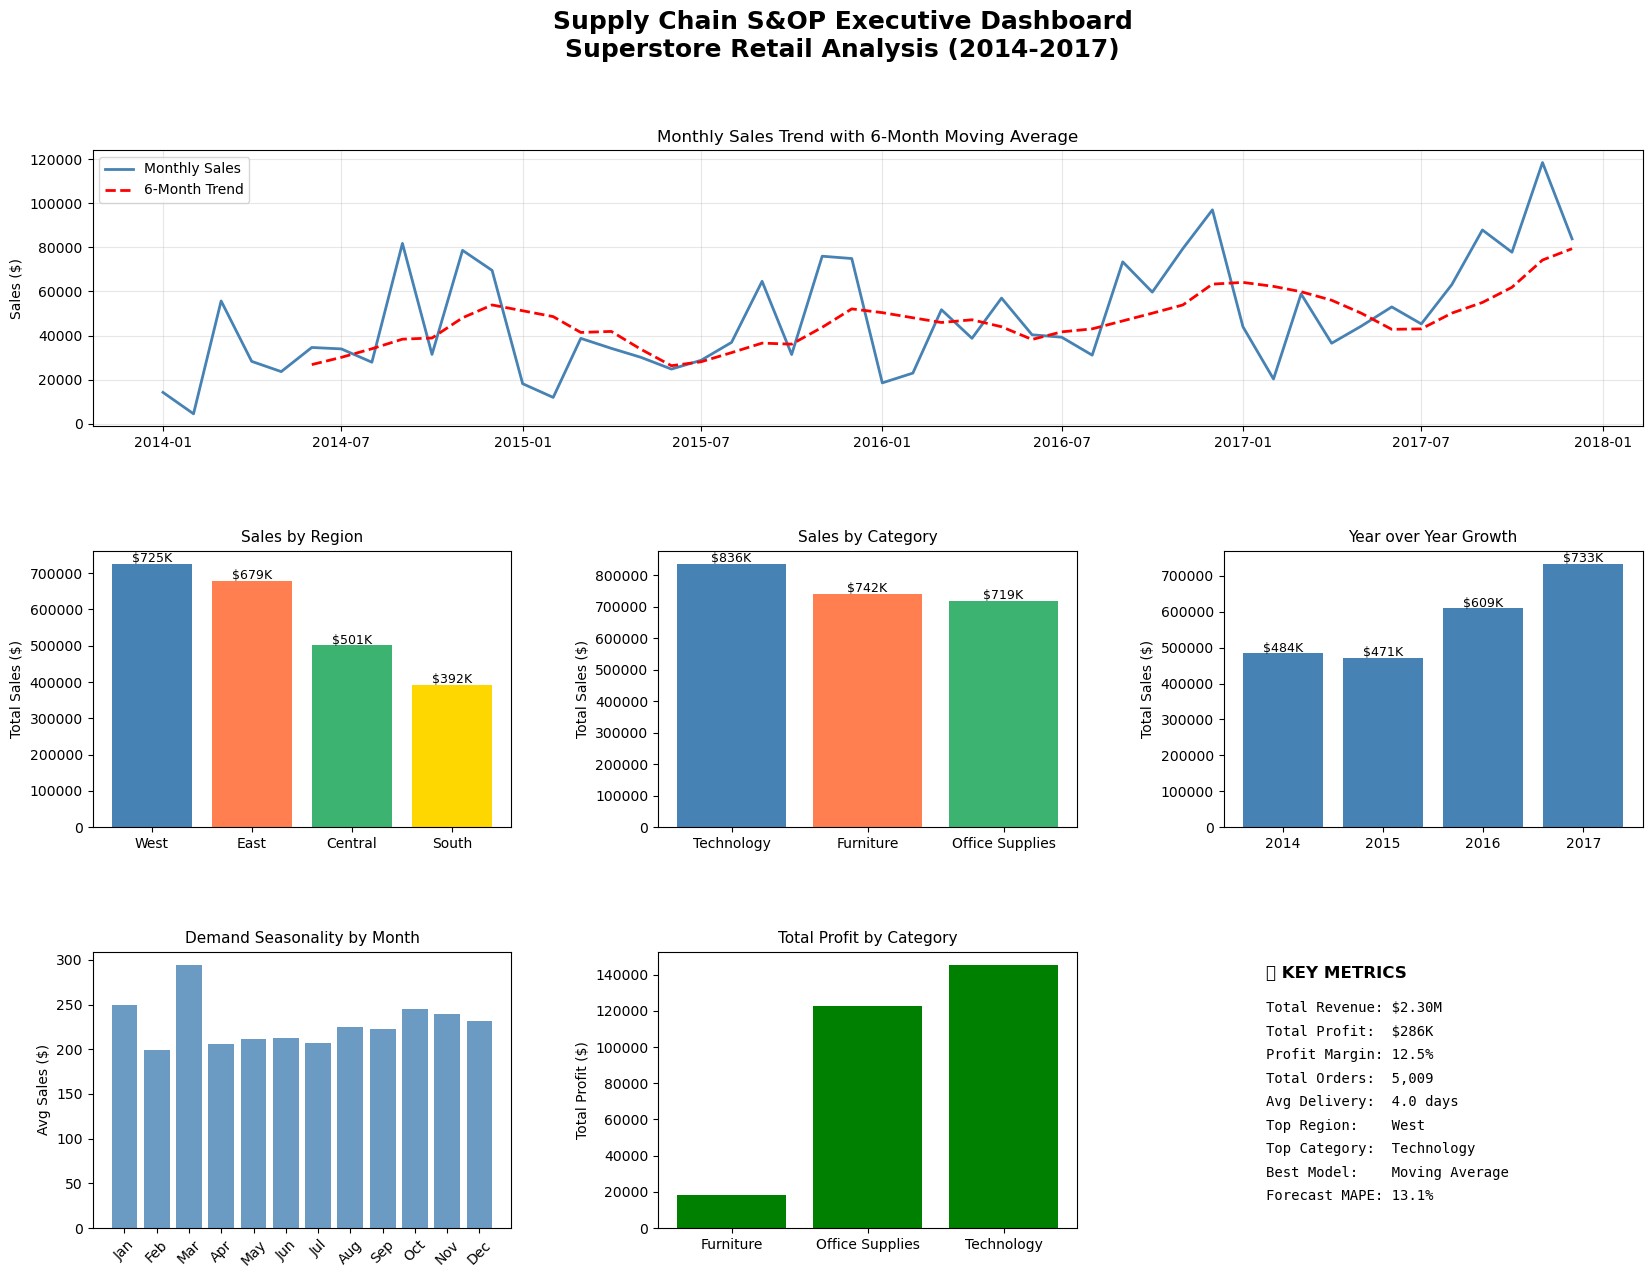

🎉 Dashboard saved!


In [2]:

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Supply Chain S&OP Executive Dashboard\nSuperstore Retail Analysis (2014-2017)', 
             fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(monthly_sales['Date'], monthly_sales['Sales'], 
         color='steelblue', linewidth=2, label='Monthly Sales')
ax1.plot(monthly_sales['Date'], 
         monthly_sales['Sales'].rolling(6).mean(),
         color='red', linewidth=2, linestyle='--', label='6-Month Trend')
ax1.set_title('Monthly Sales Trend with 6-Month Moving Average', fontsize=12)
ax1.set_ylabel('Sales ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
colors = ['steelblue', 'coral', 'mediumseagreen', 'gold']
bars = ax2.bar(regional.index, regional.values, color=colors)
ax2.set_title('Sales by Region', fontsize=11)
ax2.set_ylabel('Total Sales ($)')
for bar, val in zip(bars, regional.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val/1000:.0f}K', ha='center', fontsize=9)

ax3 = fig.add_subplot(gs[1, 1])
bars3 = ax3.bar(category.index, category.values, 
                color=['steelblue', 'coral', 'mediumseagreen'])
ax3.set_title('Sales by Category', fontsize=11)
ax3.set_ylabel('Total Sales ($)')
for bar, val in zip(bars3, category.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val/1000:.0f}K', ha='center', fontsize=9)

ax4 = fig.add_subplot(gs[1, 2])
bars4 = ax4.bar(yearly.index.astype(str), yearly.values, color='steelblue')
ax4.set_title('Year over Year Growth', fontsize=11)
ax4.set_ylabel('Total Sales ($)')
for bar, val in zip(bars4, yearly.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val/1000:.0f}K', ha='center', fontsize=9)

ax5 = fig.add_subplot(gs[2, 0])
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
ax5.bar(months, monthly_avg.values, color='steelblue', alpha=0.8)
ax5.set_title('Demand Seasonality by Month', fontsize=11)
ax5.set_ylabel('Avg Sales ($)')
ax5.tick_params(axis='x', rotation=45)

ax6 = fig.add_subplot(gs[2, 1])
profit_cat = df.groupby('Category')['Profit'].sum()
colors6 = ['green' if v > 0 else 'red' for v in profit_cat.values]
ax6.bar(profit_cat.index, profit_cat.values, color=colors6)
ax6.set_title('Total Profit by Category', fontsize=11)
ax6.set_ylabel('Total Profit ($)')

ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
kpis = [
    f"Total Revenue: ${df['Sales'].sum()/1e6:.2f}M",
    f"Total Profit:  ${df['Profit'].sum()/1e3:.0f}K",
    f"Profit Margin: {df['Profit'].sum()/df['Sales'].sum()*100:.1f}%",
    f"Total Orders:  {df['Order ID'].nunique():,}",
    f"Avg Delivery:  {df['Delivery_Days'].mean():.1f} days",
    f"Top Region:    West",
    f"Top Category:  Technology",
    f"Best Model:    Moving Average",
    f"Forecast MAPE: 13.1%",
]
ax7.text(0.1, 0.95, '📊 KEY METRICS', transform=ax7.transAxes,
         fontsize=12, fontweight='bold', va='top')
for i, kpi in enumerate(kpis):
    ax7.text(0.1, 0.82 - i*0.085, kpi, transform=ax7.transAxes,
             fontsize=10, va='top', fontfamily='monospace')

plt.savefig('../outputs/SOP_Executive_Dashboard.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("🎉 Dashboard saved!")

In [3]:
print("=" * 50)
print("   SUPPLY CHAIN DEMAND ANALYSIS — COMPLETE!")
print("=" * 50)
print(f"""
📦 Dataset:     Superstore Sales (9,994 records)
📅 Period:      2014 - 2017
🌍 Regions:     4 (West, East, Central, South)
📁 Notebooks:   4 complete notebooks

💰 Business Insights:
   • Total Revenue:    $2.30M
   • Total Profit:     $286K  
   • Profit Margin:    12.5%
   • Avg Delivery:     4.0 days
   • Top Region:       West ($725K)
   • Top Category:     Technology ($836K)
   • Peak Month:       March

🔮 Forecasting:
   • Models Tested:    Moving Average, Exp Smoothing
   • Best Model:       Moving Average
   • MAPE:             13.1%

📊 Charts Created:    10 visualizations
✅ ETL Pipeline:      Complete
✅ Demand Analysis:   Complete  
✅ Forecasting:       Complete
✅ S&OP Dashboard:    Complete
""")
print("=" * 50)

   SUPPLY CHAIN DEMAND ANALYSIS — COMPLETE!

📦 Dataset:     Superstore Sales (9,994 records)
📅 Period:      2014 - 2017
🌍 Regions:     4 (West, East, Central, South)
📁 Notebooks:   4 complete notebooks

💰 Business Insights:
   • Total Revenue:    $2.30M
   • Total Profit:     $286K  
   • Profit Margin:    12.5%
   • Avg Delivery:     4.0 days
   • Top Region:       West ($725K)
   • Top Category:     Technology ($836K)
   • Peak Month:       March

🔮 Forecasting:
   • Models Tested:    Moving Average, Exp Smoothing
   • Best Model:       Moving Average
   • MAPE:             13.1%

📊 Charts Created:    10 visualizations
✅ ETL Pipeline:      Complete
✅ Demand Analysis:   Complete  
✅ Forecasting:       Complete
✅ S&OP Dashboard:    Complete

